In [1]:
from sklearn.datasets import make_classification
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

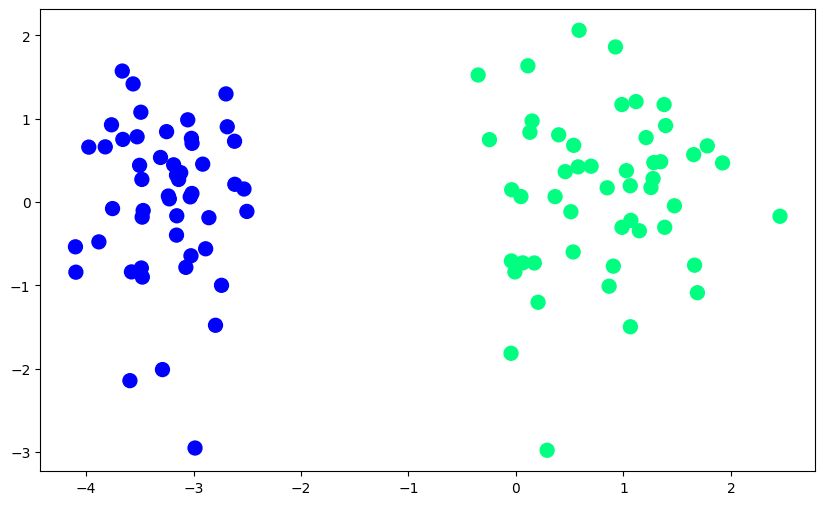

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [3]:
# Use Logistic Regression Class

lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

print(lor.coef_)
print(lor.intercept_)

m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

[[4.78924157 0.21024943]]
[5.75692534]


C:\Users\parij\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\parij\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [4]:
# Write Entropy Loss Function using Gradient Descent

def sigmoid(z):
    return 1/(1 + np.exp(-z))

def gd_entropy_loss(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]

In [5]:
coef_,intercept_ = gd_entropy_loss(X,y)

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

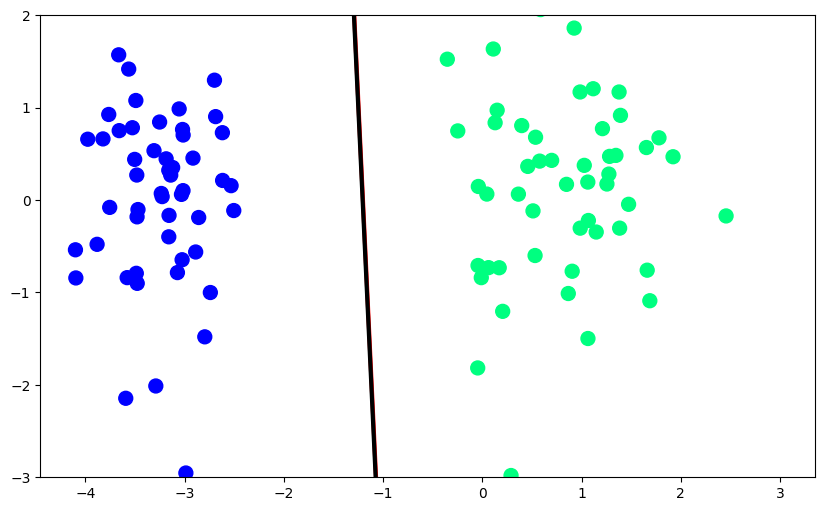

In [6]:
# Plot The Difference between Logistic Regression class and My Class

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)